In [48]:
# ==============================================================================
# LECTURE 14: Entropy change for a quenching process
# Script: Quenching_entropy
# Author: Edward Maginn, CBE 20260
# Description: 
# This notebook computes the entropy change for a quenching process, where a 
# hot workpiece is cooled by immersion in a large bath of oil. 
# We treat the workpiece and bath as a closed, adiabatic composite system, and 
# we apply the entropy balance to compute the total entropy change for each sub-system. 
# We also compute the entropy generation, which quantifies the irreversibility of the process.
# We show how as the bath size increases, the process becomes more irreversible and 
# the entropy generation increases. In the limit of an infinite bath, the 
# bath temperature remains constant and the process is maximally irreversible, 
# with the largest possible entropy generation. 
# ==============================================================================

# Entropy change for a steel part dropped into an oil bath

This notebook computes the entropy change for a **5 kg steel part** (Cp = 0.5 kJ/kg·K) dropped into a 100 kg **oil bath** (Cp = 2.5 kJ/kg·K). The steel initial temperature: **600 °C** and the oil bath initial temperature: **20 °C**. We compute the entropy change of the part, the oil, and the universe for this process. This is what we show in the lecture notes. We also compute these quantities for different oil bath masses and show how these quantities approach their limits as the bath mass → ∞.

## Physical setup and approach

1. We assume no heat loss to the surroundings (adiabatic or insulated system). The steel part and oil exchange heat until they reach a common final temperature $T_f$.

2. Use conservation of energy (First Law) to compute the final temperature $T_f$:

$\Delta U_{tot} = \Delta U_s + \Delta U_o = 0$

$m_s C_{p,s} (T_{s,i} - T_f) = m_o C_{p,o} (T_f - T_{o,i})$ 

Solving for $T_f$ gives:
$T_f = \frac{m_s C_{p,s} T_{s,i} + m_o C_{p,o} T_{o,i}}{m_s C_{p,s} + m_o C_{p,o}}$

1. Entropy change for each substance (assuming constant Cp):

$\Delta S = \int_{T_i}^{T_f} \frac{C_p}{T} \, dT = C_p \ln\frac{T_f}{T_i}$

So:

- $\Delta S_{steel} = m_s C_{p,s} \ln\frac{T_f}{T_{s,i}}$ (this will be negative since steel cools).
- $\Delta S_{oil} = m_o C_{p,o} \ln\frac{T_f}{T_{o,i}}$ (this will be positive since oil warms).

1. Universe entropy change: $\Delta S_{univ} = \Delta S_{steel} + \Delta S_{oil}$. Second law requires $\Delta S_{univ} \ge 0 $ for an irreversible spontaneous process.

2. In the **infinite bath** limit (very large oil mass), the oil temperature remains effectively at its initial temperature $T_{o,i}$. Then the heat delivered by the steel to the bath is $Q = m_s C_{p,s} (T_{s,i}-T_{o,i})$ (positive), and the bath entropy change tends to $\Delta S_{oil} = Q/T_{o,i}$ (positive). Note this $Q$ is the actual heat transferred to the bath, since we could transfer the same amount of heat to the bath reversibly or irreversibly and it would cause the same change in entropy of the bath. 

In [49]:
# Imports and parameter definitions
# We use kJ and K units so that entropy (ΔS) is in kJ/K. Convert to J/K at the end if desired.
import numpy as np
import matplotlib.pyplot as plt

# Problem parameters (constants)
m_s = 5.0           # kg, mass of steel workpiece
Cp_s = 0.50         # kJ/kg/K, heat capacity of steel 
T_si = 873.15       # K, initial steel temperature (600 °C)
Cp_o = 2.5          # kJ/kg/K, heat capacity of oil (assumed constant)
T_oi = 293.15       # K, initial oil temperature (20 °C)

# Function to compute final temperature and entropy changes for a given oil mass m_o
def compute_entropy_changes(m_o):
    """Return (Tf, dS_s, dS_o, dS_univ) for oil mass m_o.
    Method:
    - Use energy conservation to find Tf.
    - Compute entropy changes using ΔS = m Cp ln(Tf/Ti).
    Units: kJ/K for entropy (because Cp is in kJ/kg/K).
    """
    # Final temperature from energy balance (no heat loss to surroundings)
    Tf = (m_s*Cp_s*T_si + m_o*Cp_o*T_oi) / (m_s*Cp_s + m_o*Cp_o)

    # Entropy changes (kJ/K)
    dS_s = m_s * Cp_s * np.log(Tf / T_si)   # steel: negative (cooling)
    dS_o = m_o * Cp_o * np.log(Tf / T_oi)   # oil: positive (heating)
    dS_univ = dS_s + dS_o                   # This is S_gen, the entropy generation (irreversibility)

    return Tf, dS_s, dS_o, dS_univ


### Example calculations (run this cell to see numeric results)

In [50]:
# Example calculations for several oil masses.
# We show m_o = 1 kg (small bath), 100 kg (what the problem asks for in the notes), 
# 1000 kg (very large bath), and 1e6 kg (approx. infinite).
masses_to_check = [1.0, 100.0, 1000.0, 1e6]

print('Results (entropy in kJ/K):')
print('----------------------------------------------')
for m_o in masses_to_check:
    Tf, dS_s, dS_o, dS_univ = compute_entropy_changes(m_o)
    print(f"m_o = {m_o:.1g} kg: Tf = {Tf:.4f} K, ΔS_s = {dS_s:.6f}, ΔS_o = {dS_o:.6f}, ΔS_univ = {dS_univ:.6f}")
print('----------------------------------------------')
print('Notes: (1) ΔS_s is negative because steel cools. (2) ΔS_o is positive because oil warms.')
print('The universe entropy ΔS_univ should be positive (Second Law).')

Results (entropy in kJ/K):
----------------------------------------------
m_o = 1 kg: Tf = 583.1500 K, ΔS_s = -1.009157, ΔS_o = 1.719400, ΔS_univ = 0.710243
m_o = 1e+02 kg: Tf = 298.8926 K, ΔS_s = -2.680058, ΔS_o = 4.849951, ΔS_univ = 2.169893
m_o = 1e+03 kg: Tf = 293.7294 K, ΔS_s = -2.723621, ΔS_o = 4.936455, ΔS_univ = 2.212834
m_o = 1e+06 kg: Tf = 293.1506 K, ΔS_s = -2.728552, ΔS_o = 4.946263, ΔS_univ = 2.217711
----------------------------------------------
Notes: (1) ΔS_s is negative because steel cools. (2) ΔS_o is positive because oil warms.
The universe entropy ΔS_univ should be positive (Second Law).


### Visualizing convergence to infinite bath (run this cell to generate the plot)

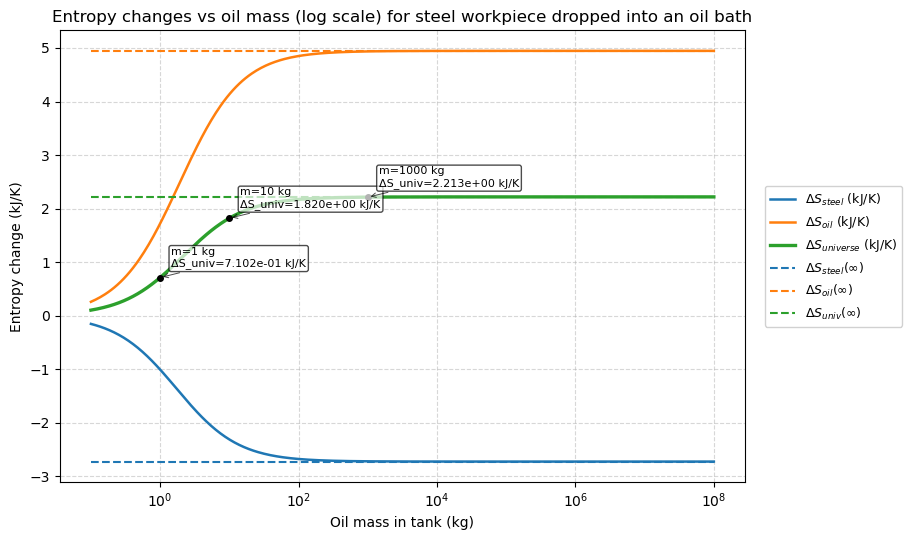

In [51]:
# Plot entropy changes as a function of oil mass, showing the approach to the infinite-bath limit.
masses = np.logspace(-1, 8, 400)
dS_s_vals = []
dS_o_vals = []
dS_univ_vals = []

for m in masses:
    Tf, dS_s, dS_o, dS_univ = compute_entropy_changes(m)
    dS_s_vals.append(dS_s)
    dS_o_vals.append(dS_o)
    dS_univ_vals.append(dS_univ)

dS_s_vals = np.array(dS_s_vals)
dS_o_vals = np.array(dS_o_vals)
dS_univ_vals = np.array(dS_univ_vals)

# Analytic infinite-bath limits (oil remains at T_o0)
Q = m_s * Cp_s * (T_si - T_oi)   # kJ, heat released by steel (positive)
dS_o_inf = Q / T_oi              # positive: bath entropy increases by Q/T_oi
dS_s_inf = m_s * Cp_s * np.log(T_oi / T_si)
dS_univ_inf = dS_s_inf + dS_o_inf

fig, ax = plt.subplots(figsize=(10,5.5))

ax.semilogx(masses, dS_s_vals, label=r'$\Delta S_{steel}$ (kJ/K)', linewidth=1.8)
ax.semilogx(masses, dS_o_vals, label=r'$\Delta S_{oil}$ (kJ/K)', linewidth=1.8)
ax.semilogx(masses, dS_univ_vals, label=r'$\Delta S_{universe}$ (kJ/K)', linewidth=2.4, color='tab:green')

# Analytic horizontal lines
ax.hlines(dS_s_inf, masses.min(), masses.max(), colors='C0', linestyles='dashed', label=r'$\Delta S_{steel}(\infty)$')
ax.hlines(dS_o_inf, masses.min(), masses.max(), colors='C1', linestyles='dashed', label=r'$\Delta S_{oil}(\infty)$')
ax.hlines(dS_univ_inf, masses.min(), masses.max(), colors='C2', linestyles='dashed', label=r'$\Delta S_{univ}(\infty)$')

# Mark the example masses with markers (no large text labels)
example_masses = [1.0, 10.0, 1000.0]
for m in example_masses:
    Tf, dS_s_pt, dS_o_pt, dS_univ_pt = compute_entropy_changes(m)
    ax.plot(m, dS_univ_pt, 'ko', markersize=4)

# Annotate the example points with small offset arrows to avoid overlapping lines/legend
for m in example_masses:
    Tf, dS_s_pt, dS_o_pt, dS_univ_pt = compute_entropy_changes(m)
    ax.annotate(f'm={int(m)} kg\nΔS_univ={dS_univ_pt:.3e} kJ/K',
                xy=(m, dS_univ_pt),
                xytext=(8, 8), textcoords='offset points',
                fontsize=8, bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
                arrowprops=dict(arrowstyle="->", lw=0.7, alpha=0.7))

# Move legend outside the plot to the right
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, framealpha=0.9)

ax.set_xscale('log')
ax.set_xlabel('Oil mass in tank (kg)')
ax.set_ylabel('Entropy change (kJ/K)')
ax.set_title('Entropy changes vs oil mass (log scale) for steel workpiece dropped into an oil bath')

ax.grid(True, which='both', ls='--', alpha=0.5)

# Adjust layout to make room for the legend and ensure annotations aren't clipped
plt.tight_layout()
plt.subplots_adjust(right=0.75)  # leave room on the right for legend
plt.show()

### Analytic infinite-bath (limit) results

For reference, the analytic infinite-bath limits (water remains at 293.15 K = 20 °C):

- Heat released by steel: $Q = m_s C_{p,s} (T_{c,i} - T_{o,i}) = 1450$ kJ (positive)
- $\Delta S_{oil,\infty} = Q/T_{o,i} = 4.949 $ kJ/K (positive)
- $\Delta S_{steel,\infty} = m_s C_{p,s} \ln(T_{o,i}/T_{s,i}) = -2.728557$ kJ/K (negative)
- $\Delta S_{univ,\infty} = 2.22$ kJ/K (positive)

These show that the universe entropy is positive (Second Law), and that the oil entropy is positive because the bath receives heat.

----
